<a href="https://colab.research.google.com/github/your-org/alexpose/blob/main/experiments/multiple-sclerosis/01_pose_extraction_from_raw_video.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 - Pose extraction from raw video

The model reads **skeleton sequences**, not image pixels directly. We run MediaPipe BlazePose over each of the 91 clips and estimate 33 landmarks per sampled frame. Each cache record keeps both its clip name and its source-video ID.

Each usable clip becomes an array of shape `(T, 33, 3)`: sampled frames, landmarks, and pixel x, pixel y, and visibility. We clean and normalize it, then cache it for later stages.


In [1]:
# --- Setup: install dependencies (Colab installs; local usually already has them) ---
import importlib, importlib.util, subprocess, sys, os

IN_COLAB = 'google.colab' in sys.modules

def _need(mod):
    return importlib.util.find_spec(mod) is None

# Light deps used by every notebook.
_pkgs = []
for mod, pip_name in [('cv2','opencv-python'), ('mediapipe','mediapipe'),
                      ('sklearn','scikit-learn'), ('pandas','pandas'),
                      ('matplotlib','matplotlib'), ('tqdm','tqdm')]:
    if _need(mod):
        _pkgs.append(pip_name)
if _pkgs:
    print('installing:', _pkgs)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *_pkgs])
else:
    print('all light dependencies already present')

all light dependencies already present


In [2]:
# --- Make `sjepa` and `ambient` importable, locally and in Colab ---
from pathlib import Path
import sys, subprocess

def _find_exp_dir():
    # Local run: this notebook sits in experiments/multiple-sclerosis.
    here = Path.cwd()
    for p in [here, *here.parents]:
        if (p / 'sjepa' / '__init__.py').exists():
            return p
    return None

EXP_DIR = _find_exp_dir()
if EXP_DIR is None:
    # Colab: clone the repo, then point at the experiment folder.
    REPO = 'https://github.com/your-org/alexpose.git'  # <-- edit to your fork
    if not Path('alexpose').exists():
        subprocess.check_call(['git', 'clone', '--depth', '1', REPO])
    EXP_DIR = Path('alexpose') / 'experiments' / 'multiple-sclerosis'

REPO_ROOT = EXP_DIR.parents[1]
for p in (str(EXP_DIR), str(REPO_ROOT)):
    if p not in sys.path:
        sys.path.insert(0, p)
print('experiment dir:', EXP_DIR)
print('repo root     :', REPO_ROOT)

experiment dir: /Users/alexmui/dev/alexpose/experiments/multiple-sclerosis
repo root     : /Users/alexmui/dev/alexpose


In [6]:
# --- Paths and profile (reads the root .env if python-dotenv is present) ---
import os
try:
    from dotenv import load_dotenv
    load_dotenv(REPO_ROOT / '.env')
except Exception:
    pass

VIDEO_DIR = EXP_DIR / 'video-data-full'
ARTIFACT_DIR = EXP_DIR / 'artifacts'
KEYPOINTS_DIR = ARTIFACT_DIR / 'keypoints-full'
IMAGES_DIR = EXP_DIR / 'images'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Pick the model size profile. 'laptop' is the fast default; set SJEPA_PROFILE=gpu
# in your .env for a larger model, or SJEPA_SMOKE=1 for a near-instant test run.
os.environ.setdefault('SJEPA_PROFILE', 'laptop')
print('SJEPA_PROFILE =', os.environ['SJEPA_PROFILE'],
      '| SJEPA_SMOKE =', os.environ.get('SJEPA_SMOKE', '0'))
print('video dir     :', VIDEO_DIR)

SJEPA_PROFILE = laptop | SJEPA_SMOKE = 0
video dir     : /Users/alexmui/dev/alexpose/experiments/multiple-sclerosis/video-data-full


## One frame at a time

The raw collection ranges from about 24 to 60 fps and uses several resolutions. The loader retains frames at an approximately 15 fps cadence and asks MediaPipe for a pose in each one. Unlike the GAVD pipeline, it reads the whole frame without bounding boxes or annotation CSVs.


In [7]:
from ambient.pose.model_management import MediaPipeModelManager
from ambient.pose.keypoint_extractor import SequenceKeypointExtractor
from sjepa.data import load_video_sequence, clean_sequence, normalize_sequence

MediaPipeModelManager().ensure_model_available()  # downloads the model once
extractor = SequenceKeypointExtractor()

CLASS_DIRS = {'normal': 'Normal', 'ms': 'MS', 'pd': 'PD'}
sample = sorted((VIDEO_DIR / CLASS_DIRS['normal']).glob('*.mp4'))[0]
seq = load_video_sequence(sample, target_fps=15, extractor=extractor, verbose=True)
print('raw sequence shape:', seq.shape, '  (frames, joints, [x, y, visibility])')

I0000 00:00:1789936439.708370 6717069 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1789936439.760410 6717071 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1789936439.768198 6717071 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


  -0wbleNgAwg_P1_01.mp4: 68 frames @ ~15fps, 54% fully detected
raw sequence shape: (68, 33, 3)   (frames, joints, [x, y, visibility])


In [8]:
seq[0]

array([[8.50557617e+02, 3.07553673e+01, 9.99971151e-01],
       [8.41822266e+02, 1.56989689e+01, 9.99968052e-01],
       [8.35395386e+02, 1.56637897e+01, 9.99972701e-01],
       [8.29645203e+02, 1.58047981e+01, 9.99965668e-01],
       [8.60588562e+02, 1.67004852e+01, 9.99965429e-01],
       [8.67128662e+02, 1.72607880e+01, 9.99971151e-01],
       [8.73578613e+02, 1.80088978e+01, 9.99962926e-01],
       [8.21671326e+02, 2.46687050e+01, 9.99976039e-01],
       [8.86469604e+02, 3.03851585e+01, 9.99968767e-01],
       [8.39104004e+02, 4.62318306e+01, 9.99948621e-01],
       [8.60414551e+02, 4.68450165e+01, 9.99925375e-01],
       [7.67260132e+02, 1.20996796e+02, 9.99982119e-01],
       [9.28713501e+02, 1.31867889e+02, 9.99929786e-01],
       [7.29231323e+02, 2.33724060e+02, 9.85023618e-01],
       [9.49220093e+02, 2.70236237e+02, 9.98072028e-01],
       [7.57866577e+02, 3.10336945e+02, 5.90443850e-01],
       [9.71186707e+02, 3.86804504e+02, 9.75419760e-01],
       [7.62503784e+02, 3.31342

## Clean and normalize

Real videos have frames where the detector loses the person. We interpolate short gaps and drop videos that are mostly empty. Then we **normalize**: we move the pelvis to the origin and scale by the torso length. This reduces translation and apparent-size differences, but does not remove viewpoint, frame-rate, resolution, compression, or detector-confidence cues.


In [9]:
cleaned = clean_sequence(seq)
normalized = normalize_sequence(cleaned)
print('cleaned:', cleaned.shape, '| normalized:', normalized.shape)
print('normalized x range:', round(float(normalized[:,:,0].min()),2),
      'to', round(float(normalized[:,:,0].max()),2))

cleaned: (48, 33, 3) | normalized: (48, 33, 3)
normalized x range: -0.71 to 1.39


## See the skeleton move

Here is the skeleton the model will actually train on. The animation draws the BlazePose stick figure over time. This is the same view we will reuse in notebook 02 to show the mask.


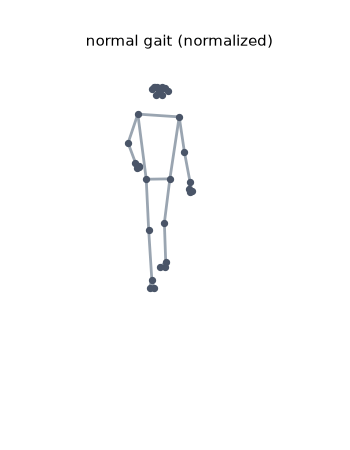

In [10]:
from sjepa.viz import skeleton_animation
from IPython.display import Image

gif = skeleton_animation(normalized, ARTIFACT_DIR / 'demo_skeleton.gif',
                         fps=15, title='normal gait (normalized)')
Image(filename=str(gif))

## Extract and cache every clip

We now process all 91 raw clips and write one `.npz` per usable clip. The final count may be smaller because clips with too little valid pose signal are skipped. The committed `g1` cache comes from an earlier 47-clip collection and must not be mixed with this versioned full cache.


In [11]:
from sjepa.data import save_sequence_npz, source_id_from_name
import numpy as np

KEYPOINTS_DIR.mkdir(parents=True, exist_ok=True)
index = []
for label, folder in CLASS_DIRS.items():
    for vid in sorted((VIDEO_DIR / folder).glob('*.mp4')):
        sid = source_id_from_name(vid.name)
        out = KEYPOINTS_DIR / f'{label}__{sid}__{vid.stem}.npz'
        if out.exists():
            with np.load(out, allow_pickle=True) as z:
                n = int(z['keypoints_norm'].shape[0])
        else:
            raw = load_video_sequence(vid, target_fps=15, extractor=extractor)
            cl = clean_sequence(raw)
            if cl is None or cl.shape[0] < 8:
                print('skip (too few valid frames):', vid.name); continue
            nm = normalize_sequence(cl)
            save_sequence_npz(out, cl, nm, 15, sid, label, vid.stem)
            n = nm.shape[0]
        index.append(dict(label=label, source_id=sid, clip_name=vid.stem, n_frames=n))

import pandas as pd
idx = pd.DataFrame(index)
idx.to_parquet(ARTIFACT_DIR / 'keypoints_index_full.parquet', index=False)
print(idx.groupby('label').agg(clips=('clip_name','count'),
                               sources=('source_id','nunique'),
                               frames=('n_frames','sum')))

I0000 00:00:1789937019.974292 6723501 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1789937020.025126 6723503 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1789937020.032533 6723503 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


skip (too few valid frames): JD1AGVpftps_P1_02.mp4


I0000 00:00:1789937032.373178 6723948 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1789937032.424600 6723951 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1789937032.432134 6723953 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


skip (too few valid frames): diCVwltkV5M_P1_01.mp4


I0000 00:00:1789937045.333797 6724447 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1789937045.384888 6724451 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1789937045.392200 6724450 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1789937058.580619 6724858 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1789937058.635314 6724860 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1789937058.642865 6724860 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1789937071.940730 6725130 gl

skip (too few valid frames): tsOMPBS277Q_P1.mp4


I0000 00:00:1789937128.711038 6726440 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1789937128.762857 6726443 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1789937128.771307 6726444 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1789937146.682860 6726898 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1789937146.747125 6726905 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1789937146.761805 6726905 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1789937161.067378 6727266 gl

        clips  sources  frames
label                         
ms         29       13    3450
normal     24       16    1427
pd         35       12    2766


### Quick checks

Shape checks verify structure, not validity. Also report accepted and rejected clips by label and source before training.


In [12]:
from sjepa.data import load_index
recs = load_index(KEYPOINTS_DIR)
assert len(recs) > 0
for r in recs[:5]:
    a = r.load_norm()
    assert a.ndim == 3 and a.shape[1] == 33 and a.shape[2] == 3
print(f'cached {len(recs)} sequences, all shaped (T, 33, 3). Ready for notebook 02.')

cached 88 sequences, all shaped (T, 33, 3). Ready for notebook 02.
